In [1]:
import numpy as np
from cq.numeric import *

D = 3
n = 2000
gs, Ts = [], []
T_matrix = T_matrix(D)
for _ in range(n):
    v, w = rand_ortho_pair(D+1)
    rho = states_to_density(v, w)
    T = (rho @ T_matrix).trace()
    g = rho_to_g(rho)
    Ts.append(T)
    gs.append(g)
gs, Ts = np.array(gs), np.array(Ts)

In [2]:
from sklearn.model_selection import train_test_split

X = np.column_stack([gs[:,1:], Ts]) #remove g_0 to avoid bias ruining implicit polynomial fit
X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)

In [3]:
from sklearn.preprocessing import PolynomialFeatures

#ChatGPT do your thing
class ImplicitPolynomial:
    def __init__(self, degree: int):
        self.degree = degree
        self.features = PolynomialFeatures(
            degree=degree,
            include_bias=True,
        )

    def fit(self, xyz: np.ndarray) -> "ImplicitPolynomial":
        """
        Fit p(x, y, z) = 0 to points of shape (n_samples, 7).
        """
        xyz = np.asarray(xyz, dtype=float)

        if xyz.ndim != 2 or xyz.shape[1] != 7:
            raise ValueError("xyz must have shape (n_samples, 7)")

        # Design matrix:
        # [1, x, y, z, x², xy, xz, y², yz, z², ...]
        A = self.features.fit_transform(xyz)

        # Solve min ||A c|| subject to ||c|| = 1.
        _, singular_values, Vt = np.linalg.svd(A, full_matrices=False)

        self.coef_ = Vt[-1]
        self.singular_values_ = singular_values
        return self

    def predict(self, xyz: np.ndarray) -> np.ndarray:
        """
        Evaluate p(x, y, z). Points on the fitted surface give values near zero.
        """
        A = self.features.transform(np.asarray(xyz, dtype=float))
        return A @ self.coef_

    def equation(self, precision: int = 5) -> str:
        names = self.features.get_feature_names_out(['g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'T'])

        terms = [
            f"{coef:+.{precision}g}*{name}"
            for coef, name in zip(self.coef_, names)
            if abs(coef) > 10 ** (-precision)
        ]
        return " ".join(terms) + " = 0"

p = ImplicitPolynomial(3)
#errors at degrees
#1: 0.025755734361205623
#2: 0.0003061402633815249
#3: 1.270077377801504e-26
p.fit(X_train)
np.var(p.predict(X_test))

np.float64(2.443840667220116e-27)

In [4]:
p.equation(2)

'-0.46*g1 +0.42*g3 -0.081*g5 +0.12*g1 g2 +0.03*g1 g4 -0.21*g1 g6 +0.36*g1 T -0.27*g2 g3 +0.32*g2 g5 +0.084*g3 g4 +0.16*g3 g6 -0.23*g3 T -0.21*g4 g5 +0.028*g5 g6 -0.12*g5 T -0.012*g1^2 g3 +0.034*g1 g2^2 -0.095*g1 g2 g4 +0.074*g1 g2 g6 -0.057*g1 g2 T +0.012*g1 g3^2 -0.016*g1 g3 g5 +0.054*g1 g4^2 -0.054*g1 g4 g6 -0.016*g1 g4 T +0.09*g1 g6 T -0.06*g1 T^2 +0.017*g2^2 g3 -0.043*g2^2 g5 -0.058*g2 g3 g6 +0.11*g2 g3 T +0.053*g2 g4 g5 +0.032*g2 g5 g6 -0.14*g2 g5 T -0.016*g3 g4^2 +0.039*g3 g4 g6 -0.02*g3 g4 T -0.062*g3 g6 T -0.015*g4^2 g5 -0.024*g4 g5 g6 +0.09*g4 g5 T -0.036*g5 g6 T +0.088*g5 T^2 = 0'

In [5]:
import sympy as sp

#ChatGPT do your thing
def to_sympy(model, variable_names=None, float_precision=None):
    """
    Convert a fitted ImplicitPolynomial model to a SymPy polynomial.

    Returns
    -------
    expr : sympy.Expr
        The polynomial expression p(x0, ..., x6).
    poly : sympy.Poly
        The same expression as a multivariate SymPy polynomial.
    symbols : tuple[sympy.Symbol, ...]
        The polynomial variables.
    """
    if not hasattr(model, "coef_"):
        raise ValueError("The model must be fitted first.")

    n_variables = model.features.n_features_in_

    if variable_names is None:
        variable_names = [f"x{i}" for i in range(n_variables)]

    if len(variable_names) != n_variables:
        raise ValueError(
            f"Expected {n_variables} variable names, "
            f"got {len(variable_names)}."
        )

    symbols = sp.symbols(" ".join(variable_names))

    expr = sp.Integer(0)

    for coefficient, powers in zip(
        model.coef_,
        model.features.powers_,
    ):
        if float_precision is None:
            coefficient_sympy = sp.Float(coefficient)
        else:
            coefficient_sympy = sp.Float(
                coefficient,
                float_precision,
            )

        monomial = sp.prod(
            symbol ** int(power)
            for symbol, power in zip(symbols, powers)
        )

        expr += coefficient_sympy * monomial

    expr = sp.expand(expr)
    poly = sp.Poly(expr, *symbols)

    return expr, poly, symbols

expr, poly, variables = to_sympy(
    p,
    variable_names=[
        'g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'T'
    ],
)

poly

Poly(0.00334425770146458*g1**3 + 1.66221203468098e-14*g1**2*g2 - 0.0116049436608177*g1**2*g3 - 2.04506550582906e-13*g1**2*g4 + 0.0085480517791123*g1**2*g5 + 2.53167278807531e-13*g1**2*g6 - 1.06423550527701e-13*g1**2*T + 5.73780172680172e-13*g1**2 + 0.0342786414411679*g1*g2**2 + 1.61124585895678e-13*g1*g2*g3 - 0.0946095961280913*g1*g2*g4 - 3.02813329966511e-13*g1*g2*g5 + 0.0740282999369685*g1*g2*g6 - 0.0567539351722644*g1*g2*T + 0.12060211224102*g1*g2 + 0.0117049019553156*g1*g3**2 + 2.71865863155085e-13*g1*g3*g4 - 0.0164515726208178*g1*g3*g5 - 4.35748659377566e-13*g1*g3*g6 + 3.47330671168766e-14*g1*g3*T - 1.11349644782432e-12*g1*g3 + 0.0535081232253003*g1*g4**2 + 2.96151991818761e-14*g1*g4*g5 - 0.0537306111839045*g1*g4*g6 - 0.0163834498740046*g1*g4*T + 0.0300363247689868*g1*g4 + 0.005350812322483*g1*g5**2 + 1.20549945893667e-13*g1*g5*g6 + 2.66602712128972e-13*g1*g5*T + 3.43622699738866e-13*g1*g5 - 0.00535081232243794*g1*g6**2 + 0.0897358506597098*g1*g6*T - 0.206392456517753*g1*g6 - 0.06

In [6]:
#filter coefficients
poly = sp.Poly.from_dict(
    {k:v for k, v in poly.as_dict().items() if abs(float(v))>1e-10},
    *poly.gens
)
poly

Poly(0.00334425770146458*g1**3 - 0.0116049436608177*g1**2*g3 + 0.0085480517791123*g1**2*g5 + 0.0342786414411679*g1*g2**2 - 0.0946095961280913*g1*g2*g4 + 0.0740282999369685*g1*g2*g6 - 0.0567539351722644*g1*g2*T + 0.12060211224102*g1*g2 + 0.0117049019553156*g1*g3**2 - 0.0164515726208178*g1*g3*g5 + 0.0535081232253003*g1*g4**2 - 0.0537306111839045*g1*g4*g6 - 0.0163834498740046*g1*g4*T + 0.0300363247689868*g1*g4 + 0.005350812322483*g1*g5**2 - 0.00535081232243794*g1*g6**2 + 0.0897358506597098*g1*g6*T - 0.206392456517753*g1*g6 - 0.0601966386285496*g1*T**2 + 0.36117983177185*g1*T - 0.459835433969062*g1 + 0.01706609361934*g2**2*g3 - 0.0433508340233354*g2**2*g5 + 0.00709424189637494*g2*g3*g4 - 0.0582851447264138*g2*g3*g6 + 0.110056060802374*g2*g3*T - 0.269347727753258*g2*g3 + 0.0528773570978211*g2*g4*g5 + 0.0320514141984843*g2*g5*g6 - 0.139884347343392*g2*g5*T + 0.316898490586693*g2*g5 - 0.00341321872380283*g3**3 + 0.00732690152499713*g3**2*g5 - 0.0163834498744705*g3*g4**2 + 0.0388855352860913*g

In [7]:
poly = sp.Poly(poly, sp.Symbol('T'))
poly

Poly((-0.0601966386285496*g1 + 0.0879228183015476*g5)*T**2 + (-0.0567539351722644*g1*g2 - 0.0163834498740046*g1*g4 + 0.0897358506597098*g1*g6 + 0.36117983177185*g1 + 0.110056060802374*g2*g3 - 0.139884347343392*g2*g5 - 0.0200655462097372*g3*g4 - 0.0622786629625654*g3*g6 - 0.229368298242538*g3 + 0.0897358506601869*g4*g5 - 0.036043589724357*g5*g6 - 0.117230424403317*g5)*T + 0.00334425770146458*g1**3 - 0.0116049436608177*g1**2*g3 + 0.0085480517791123*g1**2*g5 + 0.0342786414411679*g1*g2**2 - 0.0946095961280913*g1*g2*g4 + 0.0740282999369685*g1*g2*g6 + 0.12060211224102*g1*g2 + 0.0117049019553156*g1*g3**2 - 0.0164515726208178*g1*g3*g5 + 0.0535081232253003*g1*g4**2 - 0.0537306111839045*g1*g4*g6 + 0.0300363247689868*g1*g4 + 0.005350812322483*g1*g5**2 - 0.00535081232243794*g1*g6**2 - 0.206392456517753*g1*g6 - 0.459835433969062*g1 + 0.01706609361934*g2**2*g3 - 0.0433508340233354*g2**2*g5 + 0.00709424189637494*g2*g3*g4 - 0.0582851447264138*g2*g3*g6 - 0.269347727753258*g2*g3 + 0.0528773570978211*g2*

In [8]:
from itertools import islice

for g, T in islice(zip(gs, Ts), 10):
    print(poly.subs(dict(zip(sp.symbols(f'g:{len(g)}'), g)) | {sp.Symbol('T'):T}))

1.91127669246782e-12
-1.64896568621842e-12
-2.14271135556832e-12
-8.76382300063483e-13
-2.09247896787446e-12
-1.94300131539649e-12
7.36072314211356e-12
1.92935077636402e-12
-1.72299533581638e-12
1.44985412564580e-12


  0%|          | 0/1000 [00:00<?, ?it/s]

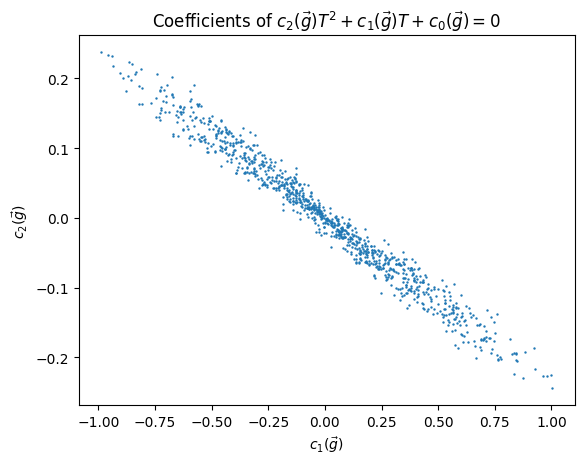

In [9]:
import matplotlib.pyplot as plt
from tqdm.notebook import trange

fig, ax = plt.subplots()

firsts, seconds = [], []
for i in trange(1000):
    g = gs[-i]
    tmp = sp.Poly(poly.subs(dict(zip(sp.symbols(f'g:{len(g)}'), g))), sp.Symbol('T'))
    firsts.append(float(tmp.as_dict().get((1,), 0)))
    seconds.append(float(tmp.as_dict().get((2,), 0)))

plt.scatter(firsts, seconds, marker='o', s=(72./fig.dpi)**2)
plt.title(r'Coefficients of $c_2(\vec{g})T^2+c_1(\vec{g})T+c_0(\vec{g})=0$')
plt.xlabel(r'$c_1(\vec{g})$')
plt.ylabel(r'$c_2(\vec{g})$')
plt.show()

---

In [10]:
p = ImplicitPolynomial(4)
#errors at degrees
#1: 0.025755734361205623
#2: 0.0003061402633815249
#3: 1.270077377801504e-26
#4: 2.4513339832974906e-26
p.fit(X_train)
np.var(p.predict(X_test))

np.float64(2.2879470489058193e-26)

In [11]:
expr, poly, variables = to_sympy(
    p,
    variable_names=[
        'g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'T'
    ],
)
poly = sp.Poly.from_dict(
    {k:v for k, v in poly.as_dict().items() if abs(float(v))>1e-10},
    *poly.gens
)
poly = sp.Poly(poly, sp.Symbol('T'))
poly

Poly(0.00944994430924595*T**4 + (0.0130686053878266*g1 + 0.00584660501521765*g2 - 0.0047737066148347*g3 - 0.0070709770482884*g4 - 0.00726712857720617*g5 - 0.00163295631979288*g6 - 0.062112625955231)*T**3 + (-0.00692933175943898*g1**2 + 0.000152611706529743*g1*g2 + 0.0193266616882782*g1*g3 + 0.0123014683709565*g1*g4 - 0.0412753582143593*g1*g5 - 0.0393582687230501*g1*g6 - 0.0612867960422186*g1 + 0.00488022907541758*g2**2 - 0.0135755362610907*g2*g3 - 0.00933017294992245*g2*g4 + 0.0261510256219707*g2*g5 + 0.00683132740044765*g2*g6 - 0.0460567335324543*g2 - 0.0473426743127721*g3**2 + 0.00145894715553473*g3*g4 + 0.130929221582386*g3*g5 + 0.0146783947910811*g3*g6 + 0.046269121440836*g3 - 0.00159908686387914*g4**2 - 0.0158452627012798*g4*g5 + 0.00976767647985112*g4*g6 + 0.0758370325573498*g4 - 0.0543842310087814*g5**2 + 0.0173866074669836*g5*g6 - 0.0140353526494446*g5 - 0.0016877737515499*g6**2 - 0.0594888226756572*g6 + 0.145495772607979)*T**2 + (-0.00801759955318517*g1**3 + 0.018400406558966*

In [12]:
poly /= poly.as_dict()[4,]
poly

1.0*T**4 + 105.820729442986*T**3*(0.0130686053878266*g1 + 0.00584660501521765*g2 - 0.0047737066148347*g3 - 0.0070709770482884*g4 - 0.00726712857720617*g5 - 0.00163295631979288*g6 - 0.062112625955231) + 105.820729442986*T**2*(-0.00692933175943898*g1**2 + 0.000152611706529743*g1*g2 + 0.0193266616882782*g1*g3 + 0.0123014683709565*g1*g4 - 0.0412753582143593*g1*g5 - 0.0393582687230501*g1*g6 - 0.0612867960422186*g1 + 0.00488022907541758*g2**2 - 0.0135755362610907*g2*g3 - 0.00933017294992245*g2*g4 + 0.0261510256219707*g2*g5 + 0.00683132740044765*g2*g6 - 0.0460567335324543*g2 - 0.0473426743127721*g3**2 + 0.00145894715553473*g3*g4 + 0.130929221582386*g3*g5 + 0.0146783947910811*g3*g6 + 0.046269121440836*g3 - 0.00159908686387914*g4**2 - 0.0158452627012798*g4*g5 + 0.00976767647985112*g4*g6 + 0.0758370325573498*g4 - 0.0543842310087814*g5**2 + 0.0173866074669836*g5*g6 - 0.0140353526494446*g5 - 0.0016877737515499*g6**2 - 0.0594888226756572*g6 + 0.145495772607979) + 105.820729442986*T*(-0.008017599553

In [13]:
for g, T in islice(zip(gs, Ts), 10):
    print(poly.subs(dict(zip(sp.symbols(f'g:{len(g)}'), g)) | {sp.Symbol('T'):T}))

8.88178419700125e-12
1.53335122377030e-11
-3.84448028967199e-12
-3.72040176443988e-11
-1.07434061646927e-11
2.83790768662584e-11
-4.77662354114727e-12
-1.73443481799040e-11
1.73344134185571e-11
-4.54747350886464e-13


  0%|          | 0/200 [00:00<?, ?it/s]

75.00362993902138


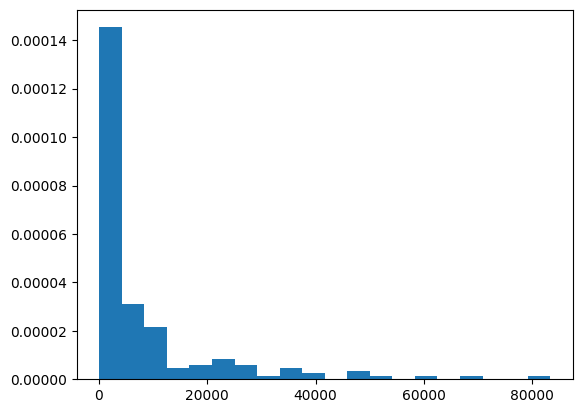

In [14]:
from cq.symbolic import vecabsq

norms = []
for i in trange(200):
    g = gs[-i]
    p = sp.Poly(poly.subs(dict(zip(sp.symbols(f'g:{len(g)}'), g))), sp.Symbol('T'))
    norms.append(float(vecabsq(p.as_list())))

print(min(norms))
plt.hist(norms, density=True, bins=20)
plt.show()